<a href="https://colab.research.google.com/github/gandharvbharde25/pitchiq/blob/master/exp%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image shape: (512, 512, 3)


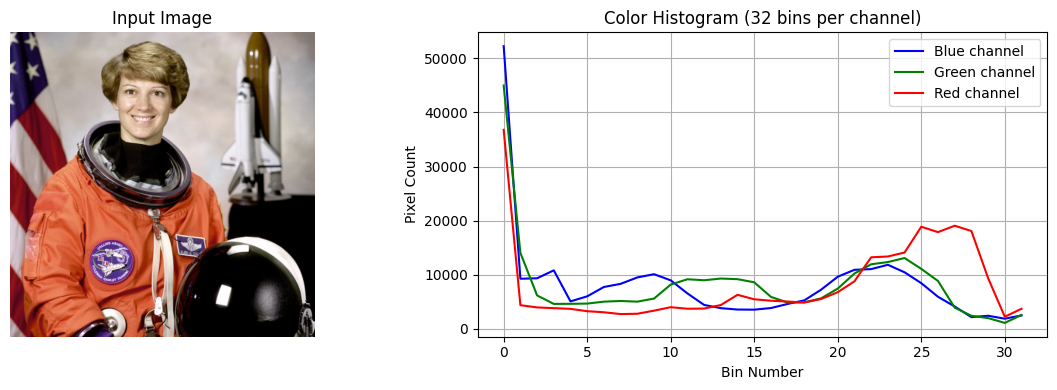


Feature vector shape: (96,)
First 10 features: [52220.  9279.  9362. 10830.  5097.  6029.  7756.  8333.  9518. 10119.]
Sum of all bins: 786432.0


In [1]:
# EXPERIMENT 3 - PART A: COLOR HISTOGRAM EXTRACTION
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Load a built-in sample image (no upload needed)
img = data.astronaut()
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

print("Image shape:", img.shape)

# Extract color histogram
colors = ('b', 'g', 'r')
channel_names = ('Blue', 'Green', 'Red')
feature_vector = []

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
for i, (col, name) in enumerate(zip(colors, channel_names)):
    hist = cv2.calcHist([img_bgr], [i], None, [32], [0, 256])
    plt.plot(hist, color=col, label=f'{name} channel')
    feature_vector.extend(hist.flatten())

plt.title('Color Histogram (32 bins per channel)')
plt.xlabel('Bin Number')
plt.ylabel('Pixel Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

feature_vector = np.array(feature_vector)
print(f"\nFeature vector shape: {feature_vector.shape}")
print(f"First 10 features: {feature_vector[:10]}")
print(f"Sum of all bins: {feature_vector.sum()}")

Number of articles: 10
Feature matrix shape: (10, 76)
Vocabulary size: 76

First 5 rows (first 10 columns):
   account  advances  agency  algorithm  announces  australia  battery  beats  \
0        0         0       0          0          0          1        0      0   
1        0         0       0          0          0          0        0      0   
2        0         0       0          0          0          0        0      1   
3        0         0       0          0          0          0        0      0   
4        0         0       0          0          0          0        1      0   

   bitcoin  chess  
0        0      0  
1        0      0  
2        0      1  
3        0      0  
4        0      0  


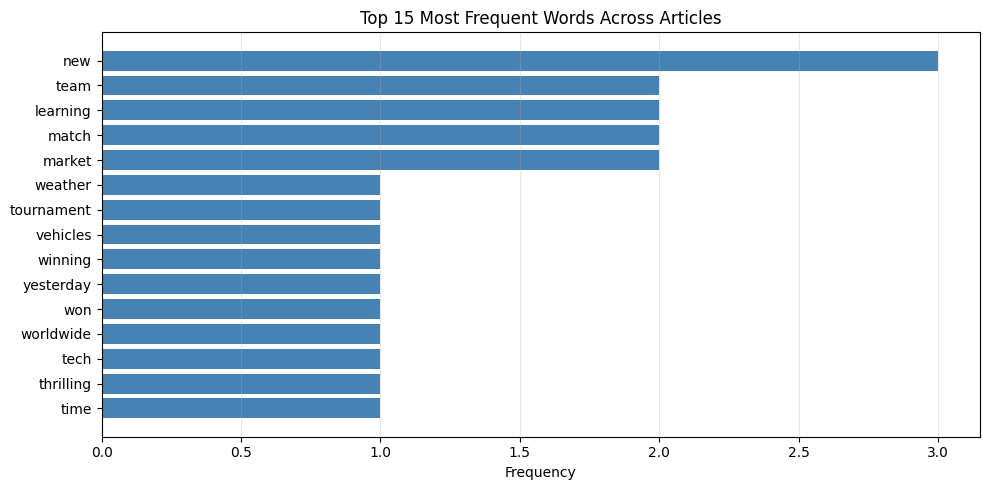


New article: Cricket and football are the most popular sports in India
Non-zero word counts:
  'cricket': 1
  'football': 1
  'india': 1


In [2]:
# EXPERIMENT 3 - PART B: WORD COUNT EXTRACTION
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Sample news articles
articles = [
    "The cricket team won the match yesterday against Australia in a thrilling game",
    "Stock market reached an all time high today with tech companies leading the gains",
    "New machine learning model beats human experts in chess tournament",
    "India successfully launches new satellite for weather forecasting and disaster management",
    "Electric vehicles market is growing rapidly worldwide as battery prices fall",
    "Football team advances to finals after winning semifinal match",
    "Bitcoin price surges as investors show renewed interest in cryptocurrency",
    "Researchers develop new deep learning algorithm for image recognition",
    "Space agency announces plans for manned mission to Mars next decade",
    "Renewable energy sources now account for record share of global electricity"
]

labels = ['sports', 'finance', 'tech', 'science', 'tech',
          'sports', 'finance', 'tech', 'science', 'science']

# Extract word-count features
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(articles)

vocab = cv.get_feature_names_out()
df = pd.DataFrame(X.toarray(), columns=vocab)
df['label'] = labels

print(f"Number of articles: {len(articles)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Vocabulary size: {len(vocab)}")
print(f"\nFirst 5 rows (first 10 columns):")
print(df.iloc[:5, :10])

# Visualize top 15 most frequent words
word_counts = X.toarray().sum(axis=0)
top_indices = word_counts.argsort()[-15:][::-1]
top_words = [vocab[i] for i in top_indices]
top_freq = [word_counts[i] for i in top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_words[::-1], top_freq[::-1], color='steelblue')
plt.title('Top 15 Most Frequent Words Across Articles')
plt.xlabel('Frequency')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Test on a new article
new_article = ["Cricket and football are the most popular sports in India"]
new_vector = cv.transform(new_article)
print(f"\nNew article: {new_article[0]}")
print("Non-zero word counts:")
for word, count in zip(vocab, new_vector.toarray()[0]):
    if count > 0:
        print(f"  '{word}': {count}")